In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vagishayadav166/sgr-photon-dataset/sgr_photon_dataset.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/vagishayadav166/sgr-photon-dataset/sgr_photon_dataset.csv')

In [3]:
display(df.head())

,M,b,b_over_bcrit,outcome,captured,r_min,phi_final,n_orbits,deflection_angle,n_steps
0,1.0,0.259808,0.050000,capture,1,1.999927,0.130,0.020690,NaN,26
1,1.0,0.264961,0.050992,capture,1,1.964085,0.135,0.021486,NaN,27
2,1.0,0.270115,0.051984,capture,1,1.930799,0.140,0.022282,NaN,28
3,1.0,0.275269,0.052975,capture,1,1.967731,0.140,0.022282,NaN,28
4,1.0,0.280422,0.053967,capture,1,1.935472,0.145,0.023077,NaN,29


In [4]:
display(df.describe())

,M,b,b_over_bcrit,captured,r_min,phi_final,n_orbits,deflection_angle,n_steps
count,8299.0,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,8299.000000,6941.000000,8299.000000
mean,1.0,116.848946,22.487590,0.163634,115.630623,3.937042,0.626600,0.772838,786.575853
std,0.0,353.296731,67.991987,0.369966,353.363281,2.429609,0.386684,1.941141,485.929198
min,1.0,0.259808,0.050000,0.000000,1.930799,0.130000,0.020690,0.003407,26.000000
25%,1.0,6.828211,1.314090,0.000000,5.425668,3.210000,0.510887,0.153407,641.000000
50%,1.0,17.519583,3.371645,0.000000,16.417836,3.355000,0.533965,0.223407,670.000000
75%,1.0,28.210954,5.429201,0.000000,27.152085,3.635000,0.578528,0.453407,726.000000
max,1.0,2598.076211,500.000000,1.000000,2597.076785,16.560000,2.635606,13.418407,3311.000000


In [5]:
print('Relationship between outcome and captured columns:')
display(df[['outcome', 'captured']].value_counts())

Relationship between outcome and captured columns:


outcome  captured
escape   0           6941
capture  1           1358
Name: count, dtype: int64

In [6]:
df = df.drop(columns=['n_steps'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8299 entries, 0 to 8298
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   M                 8299 non-null   float64
 1   b                 8299 non-null   float64
 2   b_over_bcrit      8299 non-null   float64
 3   outcome           8299 non-null   object 
 4   captured          8299 non-null   int64  
 5   r_min             8299 non-null   float64
 6   phi_final         8299 non-null   float64
 7   n_orbits          8299 non-null   float64
 8   deflection_angle  6941 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 583.7+ KB


In [7]:
from sklearn.ensemble import RandomForestRegressor

# Identify the column with missing values
column_to_impute = 'deflection_angle'

# Identify predictor columns (all numerical columns except the one to impute)
# 'outcome' is object type, so we exclude it for numerical regression here.
predictor_columns = ['M', 'b', 'b_over_bcrit', 'captured', 'r_min', 'phi_final', 'n_orbits']

# Separate data into known and missing `deflection_angle`
df_known_da = df[df[column_to_impute].notna()]
df_missing_da = df[df[column_to_impute].isna()]

if not df_missing_da.empty:
    # Prepare training data
    X_train = df_known_da[predictor_columns]
    y_train = df_known_da[column_to_impute]

    # Initialize and train the Random Forest Regressor model
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Predict missing values
    X_predict = df_missing_da[predictor_columns]
    predicted_values = model.predict(X_predict)

    # Fill the missing values in the original DataFrame
    df.loc[df[column_to_impute].isna(), column_to_impute] = predicted_values
    print(f"Missing values in '{column_to_impute}' imputed using RandomForestRegressor.")
else:
    print(f"No missing values found in '{column_to_impute}'. No imputation performed.")

# Display DataFrame info to verify no more missing values in 'deflection_angle'
df.info()

Missing values in 'deflection_angle' imputed using RandomForestRegressor.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8299 entries, 0 to 8298
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   M                 8299 non-null   float64
 1   b                 8299 non-null   float64
 2   b_over_bcrit      8299 non-null   float64
 3   outcome           8299 non-null   object 
 4   captured          8299 non-null   int64  
 5   r_min             8299 non-null   float64
 6   phi_final         8299 non-null   float64
 7   n_orbits          8299 non-null   float64
 8   deflection_angle  8299 non-null   float64
dtypes: float64(7), int64(1), object(1)
memory usage: 583.7+ KB


In [8]:
df_filtered = df[df['r_min'] >= (2 * df['M'])]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape: {df_filtered.shape}")
display(df_filtered.head())

Original DataFrame shape: (8299, 9)
Filtered DataFrame shape: (7407, 9)


,M,b,b_over_bcrit,outcome,captured,r_min,phi_final,n_orbits,deflection_angle
31,1.0,0.419573,0.080747,capture,1,2.001645,0.210,0.033423,3.062357
56,1.0,0.548415,0.105543,capture,1,2.000527,0.275,0.043768,3.062357
58,1.0,0.558723,0.107526,capture,1,2.001977,0.280,0.044563,3.062357
79,1.0,0.666951,0.128355,capture,1,2.000212,0.335,0.053317,3.062357
81,1.0,0.677258,0.130338,capture,1,2.001554,0.340,0.054113,3.062357


In [9]:
df = df_filtered.copy()
del df_filtered
print(f"DataFrame 'df' updated. New shape: {df.shape}")

DataFrame 'df' updated. New shape: (7407, 9)


In [10]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['M', 'b', 'b_over_bcrit']]
y = df['captured']

# First split: 85% for training+validation, 15% for testing
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Second split: From the training+validation set, split 70% for training and 15% for validation
# This means the validation set will be 15% of the original data, so 15 / (70 + 15) = 15/85 of X_train_val
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(0.15/0.85), random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5184, 3)
X_val shape: (1111, 3)
X_test shape: (1112, 3)
y_train shape: (5184,)
y_val shape: (1111,)
y_test shape: (1112,)


In [11]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier inspection and to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaled X_train (first 5 rows):")
display(X_train_scaled.head())
print("Scaled X_val (first 5 rows):")
display(X_val_scaled.head())
print("Scaled X_test (first 5 rows):")
display(X_test_scaled.head())

Scaled X_train (first 5 rows):


,M,b,b_over_bcrit
0,0.0,-0.304647,-0.304647
1,0.0,-0.332972,-0.332972
2,0.0,-0.285973,-0.285973
3,0.0,-0.281931,-0.281931
4,0.0,-0.308306,-0.308306


Scaled X_val (first 5 rows):


,M,b,b_over_bcrit
0,0.0,-0.306370,-0.306370
1,0.0,4.741733,4.741733
2,0.0,0.088812,0.088812
3,0.0,-0.285517,-0.285517
4,0.0,0.131223,0.131223


Scaled X_test (first 5 rows):


,M,b,b_over_bcrit
0,0.0,-0.326980,-0.326980
1,0.0,0.832311,0.832311
2,0.0,-0.183758,-0.183758
3,0.0,-0.132638,-0.132638
4,0.0,-0.339636,-0.339636


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Use X_train_scaled shape
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Changed activation to sigmoid for binary classification
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-07-25 11:35:40.346679: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    loss='binary_crossentropy', # Changed loss to binary_crossentropy
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', 'precision', 'recall'] # Changed metrics
)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [15]:
# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stopping]
)

Epoch 1/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9352 - loss: 0.2788 - precision: 0.0833 - recall: 0.0063 - val_accuracy: 0.9271 - val_loss: 0.2338 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9390 - loss: 0.1784 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9271 - val_loss: 0.1812 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9390 - loss: 0.1337 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9271 - val_loss: 0.1764 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9410 - loss: 0.1160 - precision: 0.6389 - recall: 0.0728 - val_accuracy: 0.9271 - val_loss: 0.1758 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9460 - loss: 0.1185 - precision: 0.6154 -

In [16]:
# Evaluate the model on the test set
loss, accuracy, precision, recall = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

Test Loss: 0.0765
Test Accuracy: 0.9793
Test Precision: 1.0000
Test Recall: 0.6667


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Make predictions on the test set
y_pred_proba = model.predict(X_test_scaled)
y_pred_classes = (y_pred_proba > 0.5).astype(int) # Threshold at 0.5 for binary classification

# Print classification report
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_classes))

# Calculate and print Confusion Matrix
print("Confusion Matrix on Test Set:")
conf_matrix = confusion_matrix(y_test, y_pred_classes)
print(conf_matrix)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1043
           1       1.00      0.67      0.80        69

    accuracy                           0.98      1112
   macro avg       0.99      0.83      0.89      1112
weighted avg       0.98      0.98      0.98      1112

Confusion Matrix on Test Set:
[[1043    0]
 [  23   46]]


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


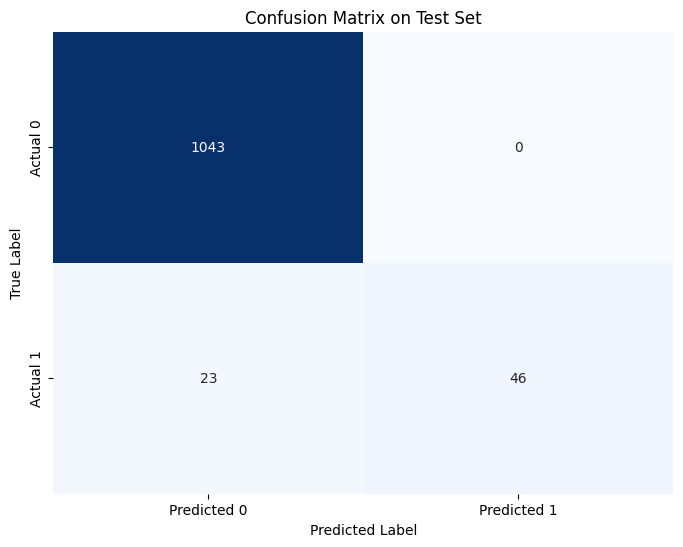

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Make predictions (probabilities) on the test set
y_pred_proba = model.predict(X_test_scaled)
# Convert probabilities to binary class labels (0 or 1)
y_pred_classes = (y_pred_proba > 0.5).astype(int)

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()